
<img src="https://reqlut2.s3.sa-east-1.amazonaws.com/reqlut-images/duoc/logo.png?v=87.8" width="180px"/>


In [1]:
import sys
import os

"""
En caso de que Python no encuentre en la ruta los otros directorios,
ejecutar esta configuración
"""

sys.path.append(os.path.abspath(".."))

# Análisis de Clustering - Dataset de Depresión Estudiantil

En este notebook, realizaremos un análisis de clustering utilizando el algoritmo K-Means sobre el dataset de depresión estudiantil ya preprocesado (codificado y escalado).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import json
import joblib
from src.carga import cargar_csv

import warnings
warnings.filterwarnings('ignore')

# Cargar el dataset
df = cargar_csv("../data/processed/Student_Depression_Dataset_codificado.csv")
df.head()

,cat__Gender_Male,cat__Sleep Duration_7-8 hours,cat__Sleep Duration_Less than 5 hours,cat__Sleep Duration_More than 8 hours,cat__Dietary Habits_Moderate,cat__Dietary Habits_Unhealthy,cat__Degree_B.Com,cat__Degree_B.Ed,cat__Degree_B.Tech,cat__Degree_BCA,...,cat__Degree_Other,bin__Have you ever had suicidal thoughts ?,bin__Family History of Mental Illness,num__Age,num__Academic Pressure,num__CGPA,num__Study Satisfaction,num__Work/Study Hours,num__Financial Stress,remainder__Depression
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.476593,1.345273,0.895400,-0.694638,-1.122130,-1.489063,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,-0.370683,-0.827109,-1.200717,1.510988,-1.122130,-0.793223,0.0
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.066087,-0.102982,-0.429182,1.510988,0.496561,-1.489063,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,0.450328,-0.102982,-1.412377,-0.694638,-0.852348,1.294297,1.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.165430,0.621145,0.321870,0.040570,-1.661693,-1.489063,0.0


## Preparación de los datos

Dado que el clustering es una técnica no supervisada, eliminaremos la columna `remainder__Depression` (si se considera como etiqueta de salida) para ver cómo se agrupan los datos basándose únicamente en las características.

In [3]:
# Separar las características para el clustering
X = df.drop(columns=['remainder__Depression']) if 'remainder__Depression' in df.columns else df

print(f"Forma de los datos para clustering: {X.shape}")

Forma de los datos para clustering: (27817, 24)


## Determinación del número óptimo de clusters mediante el Método del Codo

Este gráfico muestra cómo disminuye la inercia (WCSS) a medida que aumenta el número de clusters $K$. La inercia representa la distancia entre los datos y el centroide de su cluster, por lo que valores más bajos indican grupos más compactos.

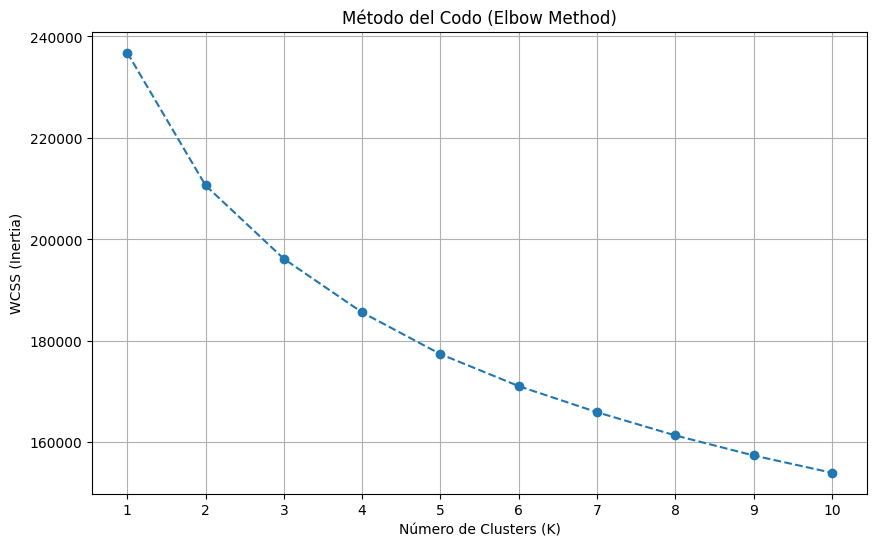

<Figure size 640x480 with 0 Axes>

In [4]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Método del Codo (Elbow Method)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.show()
plt.savefig('../outputs/plots/metrics/elbow_method.png', dpi=300, bbox_inches='tight')

## Evaluación de la calidad del clustering utilizando Silhouette Score

El gráfico de Silhouette Score evalúa qué tan bien separados y cohesionados están los clusters generados por K-Means. Este indicador toma valores entre -1 y 1:

* Valores cercanos a 1 indican clusters bien definidos.
* Valores cercanos a 0 indican solapamiento entre clusters.
* Valores negativos indican mala asignación de datos.

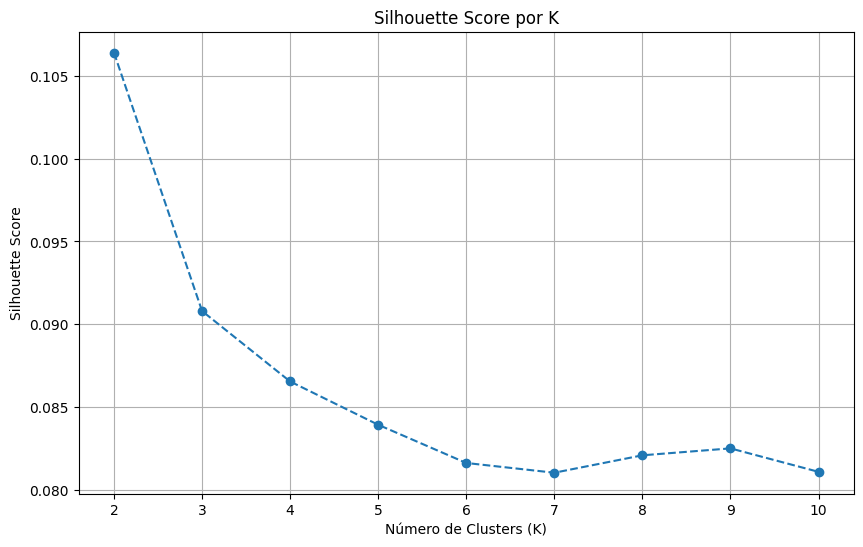

Mejor k por Silhouette: 2 (score: 0.106)


<Figure size 640x480 with 0 Axes>

In [5]:
# Silhouette Score
sil_scores = []
for k in k_range[1:]:  # Desde 2
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(10, 6))
plt.plot(k_range[1:], sil_scores, marker='o', linestyle='--')
plt.title('Silhouette Score por K')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range[1:])
plt.grid(True)
plt.show()
plt.savefig('../outputs/plots/metrics/silhouette_score.png', dpi=300, bbox_inches='tight')
k_optimo_sil = k_range[1:][np.argmax(sil_scores)]
print(f"Mejor k por Silhouette: {k_optimo_sil} (score: {max(sil_scores):.3f})")

## Interpretación de los resultados del clustering utilizando Silhouette Score


En este caso, el mejor resultado se obtiene con $K$=2, alcanzando un Silhouette Score aproximado de **0.106**. Aunque el valor no es alto, sí indica una ligera separación entre grupos, lo que sugiere que existen diferencias entre perfiles de estudiantes, pero con cierta superposición entre ellos debido a la complejidad y variabilidad de los datos

## Aplicación de K-Means

Basándonos en el gráfico anterior, seleccionaremos un valor de K (por ejemplo, K=2 o K=3) para realizar el clustering final.

In [6]:
k_optimo = 2  
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

print(f"Distribución de los clusters:\n{df['Cluster'].value_counts()}")

Distribución de los clusters:
Cluster
1    14838
0    12979
Name: count, dtype: int64


## Representación de clusters en dos dimensiones mediante PCA

Debido a que el dataset contiene muchas variables, se aplicó PCA (Principal Component Analysis) para reducir la dimensionalidad a dos componentes principales y facilitar la visualización de los clusters.

Cada punto representa un estudiante y los colores indican el cluster asignado por K-Means. La distribución observada permite identificar cómo se agrupan los estudiantes según sus características académicas, hábitos y factores relacionados con depresión.

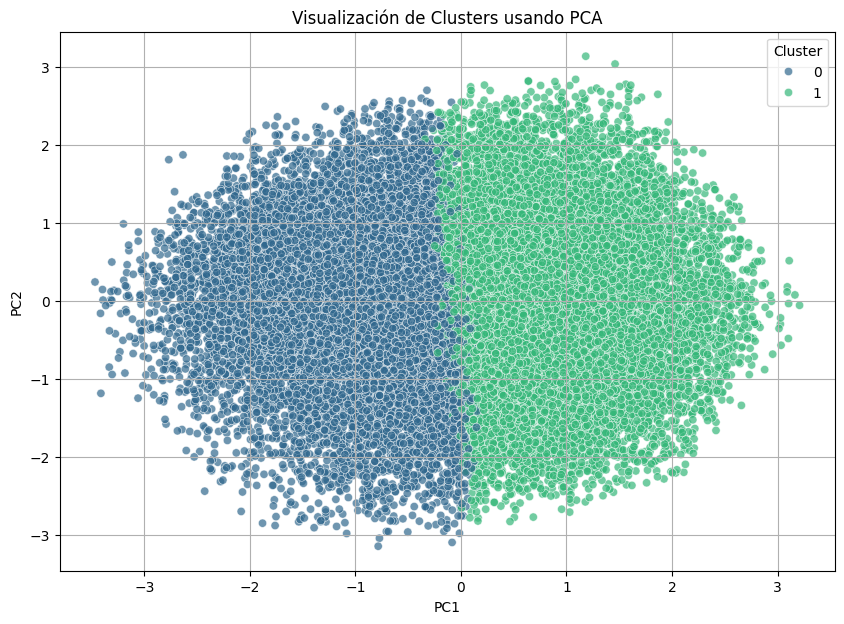

<Figure size 640x480 with 0 Axes>

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster']

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', alpha=0.7)
plt.title('Visualización de Clusters usando PCA')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()
plt.savefig('../outputs/plots/metrics/clusters_pca.png', dpi=300, bbox_inches='tight')

##

## Interpretación de los resultados del cluster PCA


Aunque los clusters presentan cierta mezcla entre sí, es posible observar tendencias de agrupamiento que indican que el algoritmo logró detectar patrones similares dentro de los datos. La superposición entre grupos puede deberse a que muchos estudiantes comparten características parecidas, haciendo más difícil una separación completamente definida

## Análisis de características promedio por cluster

La tabla muestra el promedio de cada variable para los estudiantes pertenecientes a cada cluster. Esto permite identificar las características predominantes de cada grupo y comprender mejor los perfiles detectados por el algoritmo.

In [8]:
# Agrupar por cluster y calcular la media de las variables numéricas
cluster_analysis = df.groupby('Cluster').mean()
cluster_analysis

,cat__Gender_Male,cat__Sleep Duration_7-8 hours,cat__Sleep Duration_Less than 5 hours,cat__Sleep Duration_More than 8 hours,cat__Dietary Habits_Moderate,cat__Dietary Habits_Unhealthy,cat__Degree_B.Com,cat__Degree_B.Ed,cat__Degree_B.Tech,cat__Degree_BCA,...,cat__Degree_Other,bin__Have you ever had suicidal thoughts ?,bin__Family History of Mental Illness,num__Age,num__Academic Pressure,num__CGPA,num__Study Satisfaction,num__Work/Study Hours,num__Financial Stress,remainder__Depression
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.557131,0.255104,0.281532,0.236921,0.381848,0.298020,0.055089,0.074043,0.045535,0.053394,...,0.435242,0.454272,0.468218,0.357736,-0.643553,-0.014299,0.296270,-0.316360,-0.539474,0.282610
1,0.557420,0.270522,0.312441,0.199555,0.332996,0.432538,0.053107,0.060588,0.037741,0.049670,...,0.304488,0.789123,0.497978,-0.312917,0.562924,0.012507,-0.259152,0.276724,0.471885,0.850923


Por ejemplo, se pueden observar diferencias en variables relacionadas con hábitos de sueño, satisfacción académica, presión académica y estrés financiero. Estas variaciones ayudan a interpretar cómo ciertos factores podrían estar asociados a distintos perfiles de bienestar emocional y académico dentro de la población estudiantil analizada

## Comparación visual de variables promedio entre clusters


El heatmap permite visualizar de manera comparativa las medias de cada variable en los distintos clusters. Los colores más intensos representan valores promedio más altos, mientras que los tonos más claros indican valores menores.

Esta representación facilita identificar rápidamente las variables que diferencian a los grupos de estudiantes. Por ejemplo, algunos clusters pueden presentar mayores niveles de presión académica o estrés financiero, mientras que otros muestran mejores hábitos de sueño o mayor satisfacción académica.

El gráfico ayuda a detectar patrones generales en los datos y aporta una interpretación más intuitiva de los perfiles encontrados por el algoritmo de clustering

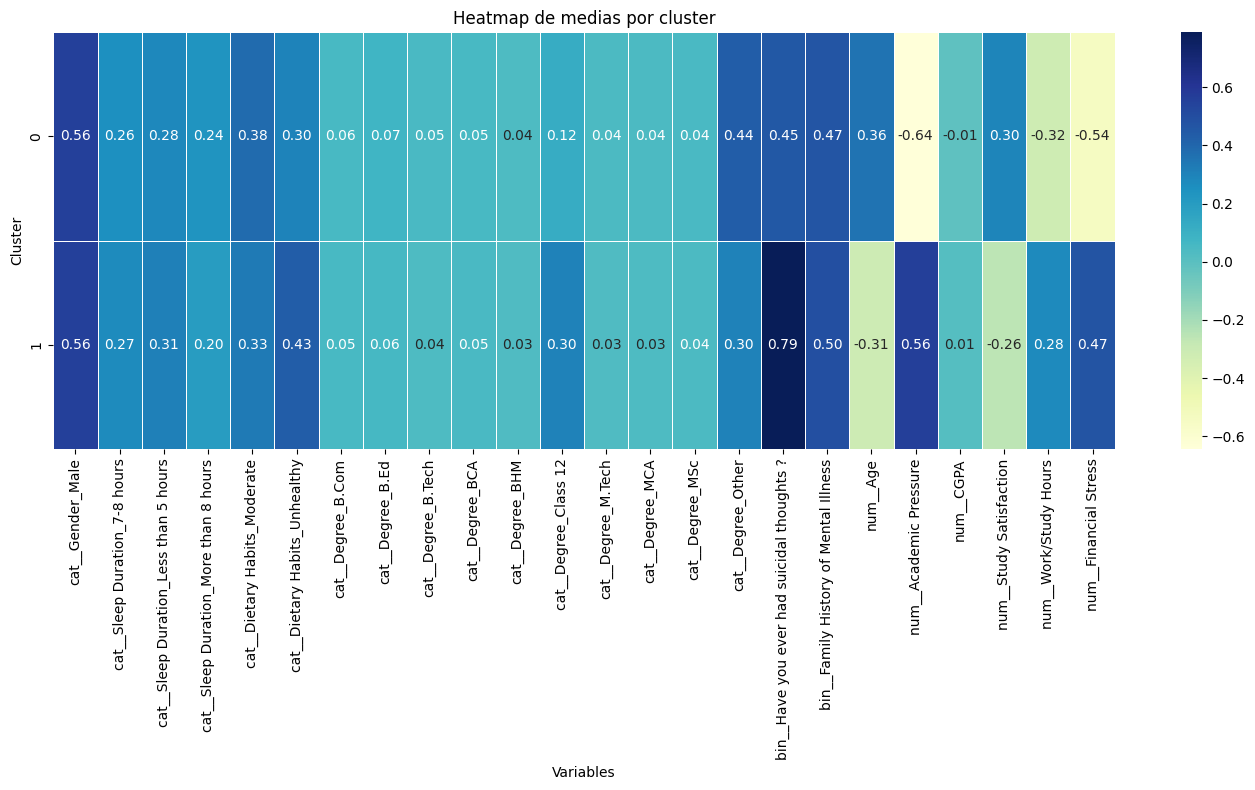

In [9]:
cluster_means = df.drop(columns=['remainder__Depression'], errors='ignore') \
                  .groupby('Cluster') \
                  .mean(numeric_only=True)

plt.figure(figsize=(14, 8))
sns.heatmap(cluster_means, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5)
plt.title('Heatmap de medias por cluster')
plt.xlabel('Variables')
plt.ylabel('Cluster')
plt.tight_layout()
plt.savefig('../outputs/plots/metrics/cluster_means_heatmap.png', dpi=300, bbox_inches='tight')

## Comparación de características predominantes entre clusters mediante Radar Chart

El radar chart permite comparar visualmente las características más representativas de cada cluster identificado por el algoritmo K-Means. Cada eje corresponde a una variable categórica relevante del dataset, mientras que las líneas de colores representan el comportamiento promedio de cada grupo de estudiantes.

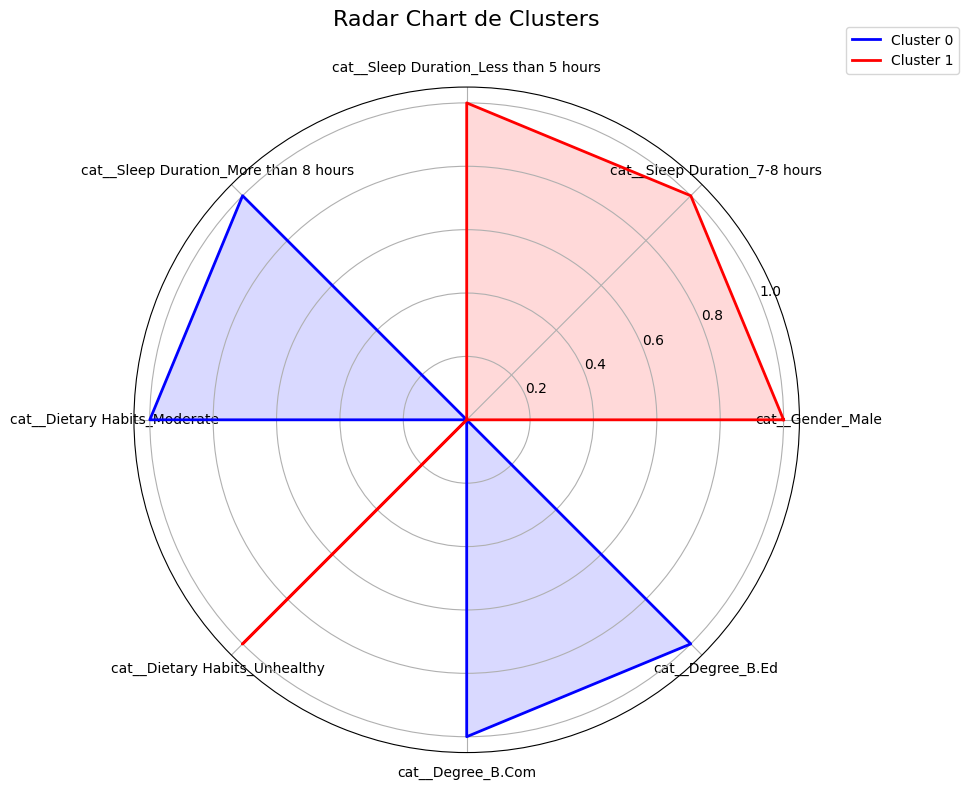

In [10]:
radar_df = cluster_means.select_dtypes(include=[np.number]).copy()

# Opcional: seleccionar solo las 8-10 variables más informativas
# Aquí se toman las 8 primeras; se puede cambiarlo por una lista manual
selected_cols = radar_df.columns[:8].tolist()

radar_data = radar_df[selected_cols].copy()

radar_data = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())
radar_data = radar_data.fillna(0)

N = len(selected_cols)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

colors = ['b', 'r', 'g', 'orange', 'purple', 'brown']

for idx, cluster in enumerate(radar_data.index):
    values = radar_data.loc[cluster].values.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Cluster {cluster}', color=colors[idx % len(colors)])
    ax.fill(angles, values, alpha=0.15, color=colors[idx % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(selected_cols, fontsize=10)
ax.set_title('Radar Chart de Clusters', y=1.08, fontsize=16)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.tight_layout()
plt.savefig('../outputs/plots/metrics/radar_chart_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

## Interpretación de resultados

En este gráfico, el Cluster 0 (azul) presenta mayores valores en variables relacionadas con:

* Dormir más de 8 horas.
* Hábitos alimenticios moderados.
* Estudiantes de grado B.Com y B.Ed.

Por otro lado, el Cluster 1 (rojo) muestra valores más altos en:

* Dormir menos de 5 horas.
* Dormir entre 7 y 8 horas.
* Hábitos alimenticios poco saludables.
* Mayor presencia de estudiantes hombres.


# Almacenamiento de métricas y exportación de resultados del clustering

En esta etapa final del análisis se guardan las métricas obtenidas del modelo de clustering, junto con el modelo entrenado y el dataset con las etiquetas de cluster asignadas.

Las métricas almacenadas incluyen:

* Número de clusters utilizados.
* Inercia del modelo (WCSS).
* Silhouette Score.
* Distribución de estudiantes por cluster.

In [11]:
metrics = {
    "n_clusters": k_optimo,
    "inertia": kmeans.inertia_,
    "silhouette_score": max(sil_scores),
    "cluster_distribution": df['Cluster'].value_counts().to_dict()
}

with open('../outputs/params/unsupervised_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

joblib.dump(kmeans, '../outputs/models/kmeans_model.pkl')
#En caso de que se desee exportar el dataset con las etiquetas de cluster asignadas,
#descomentar la siguiente línea de código
#df.to_csv('../outputs/reports/student_depression_clusters.csv', index=False)


['../outputs/models/kmeans_model.pkl']